In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
adult = fetch_ucirepo(id=2) 
  
data = adult.data.original

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


# Обработка пропусков

In [4]:
data = data[data.workclass.notna()]
data = data[data.occupation.notna()]
data = data[data['native-country'].notna()]

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 47621 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             47621 non-null  int64 
 1   workclass       47621 non-null  object
 2   fnlwgt          47621 non-null  int64 
 3   education       47621 non-null  object
 4   education-num   47621 non-null  int64 
 5   marital-status  47621 non-null  object
 6   occupation      47621 non-null  object
 7   relationship    47621 non-null  object
 8   race            47621 non-null  object
 9   sex             47621 non-null  object
 10  capital-gain    47621 non-null  int64 
 11  capital-loss    47621 non-null  int64 
 12  hours-per-week  47621 non-null  int64 
 13  native-country  47621 non-null  object
 14  income          47621 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.8+ MB


In [9]:
data.income.value_counts()

<=50K     24720
<=50K.    11360
>50K       7841
>50K.      3700
Name: income, dtype: int64

In [10]:
data['income'] = data['income'].str.strip().str.rstrip('.')

In [11]:
data.income.value_counts()

<=50K    36080
>50K     11541
Name: income, dtype: int64

In [13]:
data.workclass.value_counts()

Private             33717
Self-emp-not-inc     3838
Local-gov            3126
State-gov            1965
?                    1836
Self-emp-inc         1688
Federal-gov          1423
Without-pay            21
Never-worked            7
Name: workclass, dtype: int64

In [14]:
data = data[data.workclass != '?']

In [15]:
data.workclass.value_counts()

Private             33717
Self-emp-not-inc     3838
Local-gov            3126
State-gov            1965
Self-emp-inc         1688
Federal-gov          1423
Without-pay            21
Never-worked            7
Name: workclass, dtype: int64

In [18]:
data.education.value_counts()

HS-grad         14912
Some-college     9998
Bachelors        7708
Masters          2562
Assoc-voc        1973
11th             1628
Assoc-acdm       1519
10th             1236
7th-8th           840
Prof-school       801
9th               684
12th              593
Doctorate         567
5th-6th           464
1st-4th           227
Preschool          73
Name: education, dtype: int64

In [19]:
data.occupation.value_counts()

Prof-specialty       6110
Craft-repair         6089
Exec-managerial      6058
Adm-clerical         5589
Sales                5474
Other-service        4891
Machine-op-inspct    3006
Transport-moving     2341
Handlers-cleaners    2066
Farming-fishing      1485
Tech-support         1436
Protective-serv       981
Priv-house-serv       238
Armed-Forces           14
?                       7
Name: occupation, dtype: int64

In [20]:
data = data[data.occupation != '?']

In [21]:
data.relationship.value_counts()

Husband           18907
Not-in-family     11841
Own-child          6685
Unmarried          4847
Wife               2120
Other-relative     1378
Name: relationship, dtype: int64

In [22]:
data.race.value_counts()

White                 39271
Black                  4320
Asian-Pac-Islander     1382
Amer-Indian-Eskimo      435
Other                   370
Name: race, dtype: int64

In [23]:
data.sex.value_counts()

Male      30935
Female    14843
Name: sex, dtype: int64

In [25]:
data['native-country'].value_counts()

United-States                 41292
Mexico                          903
?                               556
Philippines                     283
Germany                         193
Puerto-Rico                     175
Canada                          163
El-Salvador                     147
India                           147
Cuba                            133
England                         119
China                           113
Jamaica                         103
South                           101
Italy                           100
Dominican-Republic               97
Japan                            89
Guatemala                        86
Vietnam                          83
Columbia                         82
Poland                           81
Haiti                            69
Portugal                         62
Iran                             56
Taiwan                           55
Greece                           49
Nicaragua                        48
Peru                        

In [26]:
data = data[data['native-country'] != '?']

In [27]:
data.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,45222.000000,4.522200e+04,45222.000000,45222.000000,45222.000000,45222.000000
mean,38.547941,1.897347e+05,10.118460,1101.430344,88.595418,40.938017
std,13.217870,1.056392e+05,2.552881,7506.430084,404.956092,12.007508
min,17.000000,1.349200e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.173882e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783160e+05,10.000000,0.000000,0.000000,40.000000
75%,47.000000,2.379260e+05,13.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


# Визуализация

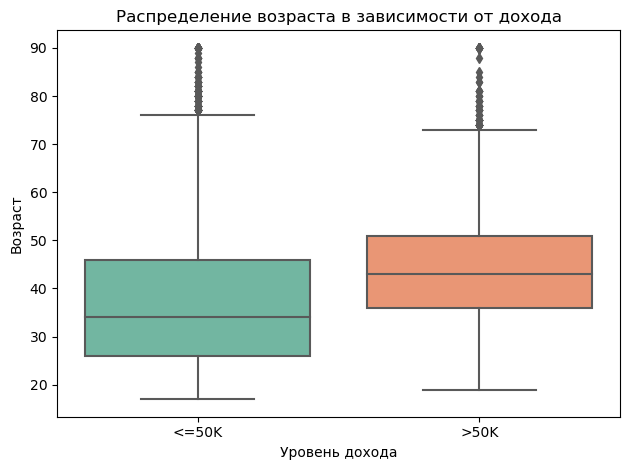

In [32]:
#plt.subplot(1, 2, 2)
sns.boxplot(x=data['income'], y=data['age'], palette='Set2')
plt.title('Распределение возраста в зависимости от дохода')
plt.xlabel('Уровень дохода')
plt.ylabel('Возраст')

plt.tight_layout()
plt.show()

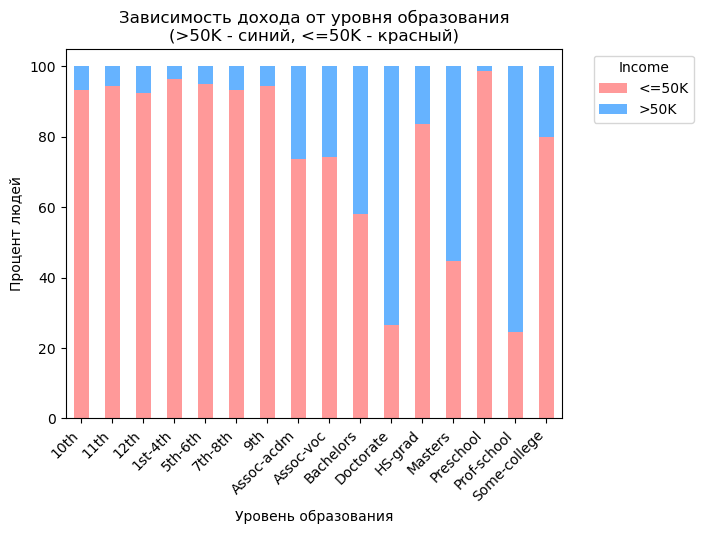

In [29]:
education_income = pd.crosstab(data['education'], data['income'], normalize='index') * 100
education_income.plot(kind='bar', stacked=True, ax=plt.gca(), color=['#ff9999','#66b3ff'])
plt.title('Зависимость дохода от уровня образования\n(>50K - синий, <=50K - красный)', fontsize=12)
plt.xlabel('Уровень образования')
plt.ylabel('Процент людей')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Income', bbox_to_anchor=(1.05, 1))

# Преобразование категориальных данных

In [37]:
from sklearn.preprocessing import LabelEncoder

In [41]:
# Отделяем признаки (X) от целевой переменной (y)
X = data.drop(columns= 'income')
y = data[['income']]

In [50]:
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

In [51]:
categorical_features

['workclass',
 'education',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native-country']

In [54]:
X = pd.get_dummies(X, columns=categorical_features)

In [55]:
X

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,39,77516,13,2174,0,40,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,50,83311,13,0,0,13,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,38,215646,9,0,0,40,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
3,53,234721,7,0,0,40,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
4,28,338409,13,0,0,40,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48836,33,245211,13,0,0,40,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
48837,39,215419,13,0,0,36,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
48839,38,374983,13,0,0,50,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
48840,44,83891,13,5455,0,40,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0


In [43]:
le = LabelEncoder()

In [45]:
le.fit(y['income'])

LabelEncoder()

In [49]:
y = pd.Series(data=le.transform(y['income']))
y.head()

0    0
1    0
2    0
3    0
4    0
dtype: int64

# Стандартизация числовых данных

In [56]:
data.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,45222.000000,4.522200e+04,45222.000000,45222.000000,45222.000000,45222.000000
mean,38.547941,1.897347e+05,10.118460,1101.430344,88.595418,40.938017
std,13.217870,1.056392e+05,2.552881,7506.430084,404.956092,12.007508
min,17.000000,1.349200e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.173882e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783160e+05,10.000000,0.000000,0.000000,40.000000
75%,47.000000,2.379260e+05,13.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline  # используем пайплайны для удобства
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split 

In [58]:
model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

In [59]:
model

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression(max_iter=1000))])

# Обучение

Логистическая регрессия

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [66]:
model.fit(X_train, y_train)
predictions = model.predict(X_test)

In [67]:
model.score(X_train, y_train)

0.8487713187937087

In [68]:
model.score(X_test,y_test)

0.8525152017689331

Метод опорных векторов

In [69]:
from sklearn.svm import SVC

clf = make_pipeline(StandardScaler(), SVC()) 
clf.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()), ('svc', SVC())])

In [70]:
clf.score(X_train, y_train)

0.8579207783951129

In [71]:
clf.score(X_test, y_test)

0.8480928689883914